## 环境配置
### 安装配置 R 语言环境

```
## 进入 R 编程环境
conda activate LabelTransfer

## 安装所需库
conda create -n LabelTransfer -c conda-forge \
r-base=4.3 \
hdf5 \
r-hdf5r \
r-seurat \
r-seuratobject \
r-arrow \
r-tidyverse \
r-ggplot2 \
r-ggpmisc \
r-cowplot \
r-gridextra \
r-viridis \
r-hrbrthemes \
r-jsonlite \
r-remotes
```

### 安装BPcells

```
## 下载 BPcells 包
cd ~
git clone https://github.com/bnprks/BPCells.git

## 进入 R 环境
R

## 使用本地编译安装
remotes::install_local("~/BPCells/r")
```

### 安装 ipynb 文件运行 R 所需库

```
## 安装所需库
conda install -c conda-forge \
r-irkernel \
jupyter \
notebook \
ipykernel

## 进入 R 注册 kernel
IRkernel::installspec(name = "LabelTransfer", displayname = "R_LabelTransfer")

##  数据准备

### 在终端中执行，进入你的工作目录

```
cd ./data/
wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
unzip Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs.zip
```

```
curl -O https://cf.10xgenomics.com/samples/cell-exp/8.0.1/17k_Ovarian_Cancer_scFFPE/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5
```

```
curl -O https://cf.10xgenomics.com/supp/cell-exp/FLEX_Ovarian_Barcode_Cluster_Annotation.csv
```

In [1]:
# ============================================
# Cell 1: 统一初始化 - 集中管理所有配置
# ============================================

# 1. 设置工作目录
setwd("/home/ailab/caohao/AdaDiss/")

# 2. 定义所有文件路径
paths <- list(
    # ===== 输入数据路径 =====
    # Flex 数据
    flex_h5 = "./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5",
    flex_annotation = "./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv",
    flex_bpcells_dir = "./data/flex_counts_bpcells/",
    flex_cache = "./data/flex_data_processed.rds",
    
    # Xenium 数据
    xenium_dir = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/",
    xenium_bpcells_dir = "./data/xenium_counts_bpcells/",
    xenium_cache = "./data/xenium_data_processed.rds",
    xenium_gene_panel = "./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/gene_panel.json",
    
    # ===== 输出数据路径 =====
    # 预测结果导出
    output_csv = "./results/cell_groups.csv",                    # 基础预测结果
    output_full_csv = "./results/cell_predictions_full.csv",     # 完整预测结果（含所有分数列）
    output_gnn_csv = "./data/xenium_for_gnn.csv",
    output_rds = "./results/xenium_annotated_final.rds",         # 完整Seurat对象
    output_flex_rds = "./results/flex_reference.rds",            # Flex参考对象（可选）
    
    # 分析中间结果（可选）
    output_stats = "./results/prediction_stats.txt",             # 统计报告
    output_plots = "./results/plots/"                           # 可视化图表保存目录
)

# 3. 设置分析参数
params <- list(
    # Flex QC 参数
    flex_min_counts = 200,
    flex_max_counts = 10000,
    flex_max_mt = 10,
    
    # Xenium 参数
    xenium_npcs = 50,
    xenium_dims = 1:30,
    xenium_resolution = 0.6,
    xenium_cluster_name = "clusters",
    
    # 标签转移参数
    transfer_dims = 1:30,
    transfer_k = 50,
    
    # 可视化参数
    seed = 42,
    
    # 输出控制
    save_intermediate = TRUE,      # 是否保存中间结果
    verbose = TRUE                 # 是否打印详细信息
)

# ========== 关键：细胞类型映射表 ==========
# 4. 将分数列名（点号格式）映射到原始细胞类型名
cell_type_mapping <- c(
    # 分数列名格式 → 原始格式
    "Tumor.Associated.Fibroblasts" = "Tumor Associated Fibroblasts",
    "Endothelial.Cells" = "Endothelial Cells",
    "Stromal.Associated.Fibroblasts" = "Stromal Associated Fibroblasts",
    "T...NK.Cells" = "T & NK Cells",
    "Malignant.Cells.Lining.Cyst" = "Malignant Cells Lining Cyst",
    "Proliferative.Tumor.Cells" = "Proliferative Tumor Cells",
    "Tumor.Cells" = "Tumor Cells",
    "Pericytes" = "Pericytes",
    "Granulosa.Cells" = "Granulosa Cells",
    "Macrophages" = "Macrophages",
    "MT.High..Jun..Fos..Tumor.Cells" = "MT-High, Jun+/Fos+ Tumor Cells",
    "VEGFA..Tumor.Cells" = "VEGFA+ Tumor Cells",
    "Smooth.Muscle.Cells" = "Smooth Muscle Cells",
    "Inflammatory.Tumor.Cells" = "Inflammatory Tumor Cells",
    "Ciliated.Epithelial.Cells" = "Ciliated Epithelial Cells",
    "Fallopian.Tube.Epithelium" = "Fallopian Tube Epithelium"
)

# 反向映射表（原始格式 → 分数列名格式）
reverse_mapping <- setNames(names(cell_type_mapping), cell_type_mapping)

# 打印映射表验证
cat("\n📋 细胞类型映射表:\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
for (i in 1:length(cell_type_mapping)) {
    cat(sprintf("  %-35s → %-40s\n", 
                names(cell_type_mapping)[i], 
                cell_type_mapping[i]))
}
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")


# 5. 创建输出目录（如果不存在）
if (!dir.exists(dirname(paths$output_csv))) {
    dir.create(dirname(paths$output_csv), recursive = TRUE)
    cat("📁 创建输出目录:", dirname(paths$output_csv), "\n")
}

if (!dir.exists(paths$output_plots)) {
    dir.create(paths$output_plots, recursive = TRUE)
    cat("📁 创建图表目录:", paths$output_plots, "\n")
}

# 6. 设置随机种子
set.seed(params$seed)

# 7. 加载所有必要的包
cat("📦 加载R包...\n")
suppressPackageStartupMessages({
    # 核心包
    library(Seurat)
    library(BPCells)
    library(SeuratObject)
    library(SeuratDisk)
    library(tidyverse)
    library(jsonlite)
    
    # 绘图包
    library(ggplot2)
    library(ggpmisc)
    library(scales)
    library(cowplot)
    library(gridExtra)
    library(viridis)
    library(hrbrthemes)
})

# 8. 设置Seurat内存限制
options(future.globals.maxSize = 1e9)

# 9. 定义缓存加载函数
load_or_process <- function(cache_file, process_func, force_reprocess = FALSE) {
    if (!force_reprocess && file.exists(cache_file)) {
        cat("📦 从缓存加载:", basename(cache_file), "\n")
        return(readRDS(cache_file))
    } else {
        if (force_reprocess) cat("🔄 强制重新处理...\n")
        else cat("🔄 首次运行，正在处理...\n")
        obj <- process_func()
        # 确保缓存目录存在
        cache_dir <- dirname(cache_file)
        if (!dir.exists(cache_dir)) {
            dir.create(cache_dir, recursive = TRUE)
        }
        saveRDS(obj, cache_file)
        cat("✅ 已保存到:", basename(cache_file), "\n")
        return(obj)
    }
}

# 10. 打印配置信息
cat("\n✅ 环境初始化完成\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
cat("📁 工作目录:", getwd(), "\n")
cat("\n📂 输入数据路径:\n")
cat("  - Flex数据:", paths$flex_h5, "\n")
cat("  - Flex注释:", paths$flex_annotation, "\n")
cat("  - Xenium数据:", paths$xenium_dir, "\n")
cat("\n📤 输出数据路径:\n")
cat("  - 预测结果:", paths$output_csv, "\n")
cat("  - 完整预测:", paths$output_full_csv, "\n")
cat("  - Seurat对象:", paths$output_rds, "\n")
cat("  - 统计报告:", paths$output_stats, "\n")
cat("  - 图表目录:", paths$output_plots, "\n")
cat("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n")


📋 细胞类型映射表:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tumor.Associated.Fibroblasts        → Tumor Associated Fibroblasts            
  Endothelial.Cells                   → Endothelial Cells                       
  Stromal.Associated.Fibroblasts      → Stromal Associated Fibroblasts          
  T...NK.Cells                        → T & NK Cells                            
  Malignant.Cells.Lining.Cyst         → Malignant Cells Lining Cyst             
  Proliferative.Tumor.Cells           → Proliferative Tumor Cells               
  Tumor.Cells                         → Tumor Cells                             
  Pericytes                           → Pericytes                               
  Granulosa.Cells                     → Granulosa Cells                         
  Macrophages                         → Macrophages                             
  MT.High..Jun..Fos..Tumor.Cells      → MT-High, Jun+/Fos+ Tumor Cells          
  VEGFA..Tumor.Cells                  → VEGF

Warning message:
“package ‘BPCells’ was built under R version 4.5.2”
Warning message:
“package ‘SeuratDisk’ was built under R version 4.5.2”



✅ 环境初始化完成
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📁 工作目录: /home/ailab/caohao/AdaDiss 

📂 输入数据路径:
  - Flex数据: ./data/17k_Ovarian_Cancer_scFFPE_count_filtered_feature_bc_matrix.h5 
  - Flex注释: ./data/FLEX_Ovarian_Barcode_Cluster_Annotation.csv 
  - Xenium数据: ./data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs/ 

📤 输出数据路径:
  - 预测结果: ./results/cell_groups.csv 
  - 完整预测: ./results/cell_predictions_full.csv 
  - Seurat对象: ./results/xenium_annotated_final.rds 
  - 统计报告: ./results/prediction_stats.txt 
  - 图表目录: ./results/plots/ 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [2]:
# ============================================
# Cell 2: 加载Flex参考数据（带缓存机制）
# ============================================

process_flex_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    flex_obj <- Read10X_h5(paths$flex_h5) %>% CreateSeuratObject()
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$flex_bpcells_dir)) {
        write_matrix_dir(mat = flex_obj[["RNA"]]$counts, dir = paths$flex_bpcells_dir)
    }
    flex_obj[['RNA']]$counts <- open_matrix_dir(dir = paths$flex_bpcells_dir)
    
    cat("  步骤3: 计算线粒体比例...\n")
    flex_obj[["percent.mt"]] <- PercentageFeatureSet(flex_obj, pattern = "^MT-")
    
    cat("  步骤4: QC过滤...\n")
    n_before <- ncol(flex_obj)
    flex_obj <- subset(flex_obj, 
                       subset = nCount_RNA > params$flex_min_counts & 
                                nCount_RNA < params$flex_max_counts & 
                                percent.mt < params$flex_max_mt)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(flex_obj), "细胞\n")
    
    cat("  步骤5: 添加细胞类型注释...\n")
    if (file.exists(paths$flex_annotation)) {
        ann_df <- read.csv(paths$flex_annotation)
        cell_types <- setNames(ann_df$Cell.Annotation, ann_df$Barcode)
        # 只保留当前数据中存在的细胞
        cell_types <- cell_types[names(cell_types) %in% colnames(flex_obj)]
        flex_obj <- AddMetaData(flex_obj, cell_types[colnames(flex_obj)], "cell_type")
        cat("    注释了", length(unique(flex_obj$cell_type)), "种细胞类型\n")
    } else {
        warning("找不到注释文件: ", paths$flex_annotation)
    }
    
    return(flex_obj)
}

# 加载或处理Flex数据
flex_data.obj <- load_or_process(paths$flex_cache, process_flex_data)

cat("\n📊 Flex数据摘要:\n")
cat("  - 细胞数量:", ncol(flex_data.obj), "\n")
cat("  - 基因数量:", nrow(flex_data.obj), "\n")
cat("  - 细胞类型:", length(unique(flex_data.obj$cell_type)), "\n")

📦 从缓存加载: flex_data_processed.rds 

📊 Flex数据摘要:
  - 细胞数量: 17050 
  - 基因数量: 18082 
  - 细胞类型: 16 


In [3]:
# ============================================
# Cell 3: 加载Xenium数据（带缓存机制）
# ============================================

process_xenium_data <- function() {
    cat("  步骤1: 加载原始数据...\n")
    xenium_obj <- LoadXenium(paths$xenium_dir, fov = "fov", molecule.coordinates = FALSE)
    DefaultAssay(xenium_obj) <- "Xenium"
    
    cat("  步骤2: 配置BPCells磁盘存储...\n")
    if (!dir.exists(paths$xenium_bpcells_dir)) {
        write_matrix_dir(mat = xenium_obj[["Xenium"]]$counts, dir = paths$xenium_bpcells_dir)
    }
    xenium_obj[['Xenium']]$counts <- open_matrix_dir(dir = paths$xenium_bpcells_dir)
    
    cat("  步骤3: 过滤空细胞...\n")
    n_before <- ncol(xenium_obj)
    xenium_obj <- subset(xenium_obj, subset = nCount_Xenium > 0)
    cat("    过滤前:", n_before, "细胞 → 过滤后:", ncol(xenium_obj), "细胞\n")
    
    cat("  步骤4: 添加log转换元数据...\n")
    xenium_obj@meta.data$nCount_Xenium_log <- log1p(xenium_obj@meta.data$nCount_Xenium)
    xenium_obj@meta.data$nFeature_Xenium_log <- log1p(xenium_obj@meta.data$nFeature_Xenium)
    
    return(xenium_obj)
}

# 加载或处理Xenium数据
xenium.obj <- load_or_process(paths$xenium_cache, process_xenium_data)

cat("\n📊 Xenium数据摘要:\n")
cat("  - 细胞数量:", ncol(xenium.obj), "\n")
cat("  - 基因数量:", nrow(xenium.obj), "\n")

📦 从缓存加载: xenium_data_processed.rds 

📊 Xenium数据摘要:
  - 细胞数量: 406611 
  - 基因数量: 5101 


📈 计算基因表达相关性...


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 41 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”


✅ 相关性分析完成


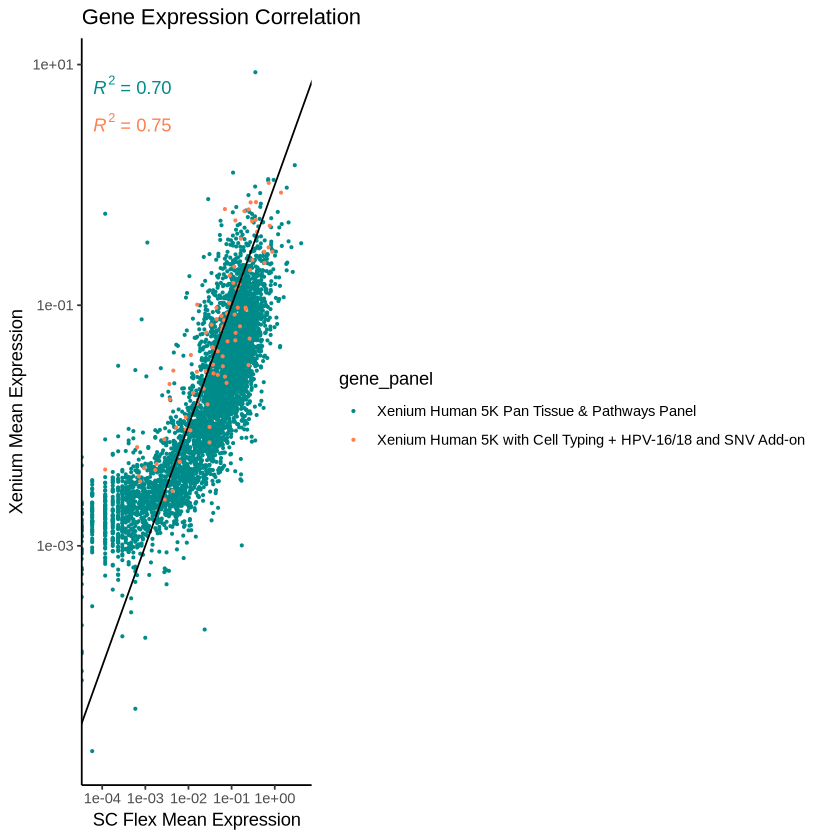

In [4]:
# ============================================
# Cell 4: 基因表达相关性分析（可选，如失败可跳过）
# ============================================

if (file.exists(paths$xenium_gene_panel)) {
    cat("📈 计算基因表达相关性...\n")
    
    # 定义函数
    get_gex_means <- function(xenium_obj, flex_obj) {
        xen_means <- data.frame(
            mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
            gene = rownames(xenium_obj[["Xenium"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        flex_means <- data.frame(
            mean_counts = rowMeans(flex_obj[["RNA"]]$counts),
            gene = rownames(flex_obj[["RNA"]]$counts)
        ) %>% arrange(desc(mean_counts)) %>% mutate(Rank = 1:n())
        
        return(merge(xen_means, flex_means, by.x = "gene", by.y = "gene", all.x = TRUE))
    }
    
    # 读取基因面板
    gene_panel <- fromJSON(paths$xenium_gene_panel)
    targets <- gene_panel$payload$targets
    panel_source <- setNames(
        data.frame(cbind(targets$source$identity$name, targets$type$data$name)), 
        c("gene_panel", "gene")
    )
    
    # 合并数据
    merged_means <- get_gex_means(xenium.obj, flex_data.obj)
    merged_means <- merge(merged_means, panel_source, by.x = "gene", by.y = "gene", all.x = TRUE) %>%
                   na.omit() %>% arrange(gene_panel)
    
    # 绘图
    p_cor <- ggplot(merged_means, aes(x = mean_counts.y, y = mean_counts.x, color = gene_panel)) +
        geom_point(size = 0.5) +
        scale_colour_manual(values = c("darkcyan", "coral")) +
        stat_poly_eq() +
        scale_x_log10() + scale_y_log10() +
        xlab("SC Flex Mean Expression") + ylab("Xenium Mean Expression") +
        ggtitle("Gene Expression Correlation") +
        theme_classic() +
        geom_abline(slope = 1, intercept = 0)
    
    print(p_cor)
    cat("✅ 相关性分析完成\n")
} else {
    cat("⚠️ 跳过相关性分析（找不到gene_panel.json）\n")
}

🔧 处理Flex参考数据...


Normalizing layer: counts

Finding variable features for layer counts

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17050
Number of edges: 598740

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9287
Number of communities: 17
Elapsed time: 4 seconds
✅ Flex数据处理完成


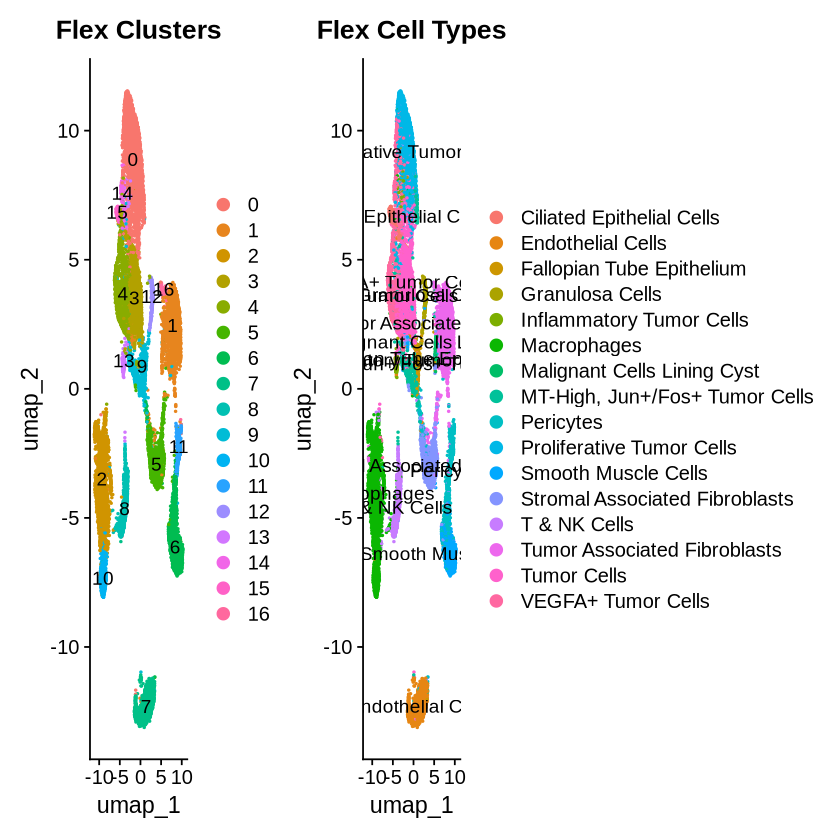

In [5]:
# ============================================
# Cell 5: Flex参考数据处理
# ============================================

cat("🔧 处理Flex参考数据...\n")

DefaultAssay(flex_data.obj) <- "RNA"
flex_data.obj <- NormalizeData(flex_data.obj) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA(verbose = FALSE) %>%
                 RunUMAP(dims = 1:15, verbose = FALSE) %>%
                 FindNeighbors(dims = 1:15) %>%
                 FindClusters(resolution = 0.5)

# 可视化
p1 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "RNA_snn_res.0.5", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Clusters")
p2 <- DimPlot(flex_data.obj, reduction = "umap", group.by = "cell_type", 
              label = TRUE, pt.size = 0.2) + ggtitle("Flex Cell Types")

# 显示
print(p1 + p2)

cat("✅ Flex数据处理完成\n")

🔧 处理Xenium数据（细胞数: 406611 ）


Normalizing layer: counts



Finding variable features for layer counts

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 406611
Number of edges: 10966759

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8390
Number of communities: 54
Elapsed time: 723 seconds


35 singletons identified. 19 final clusters.

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



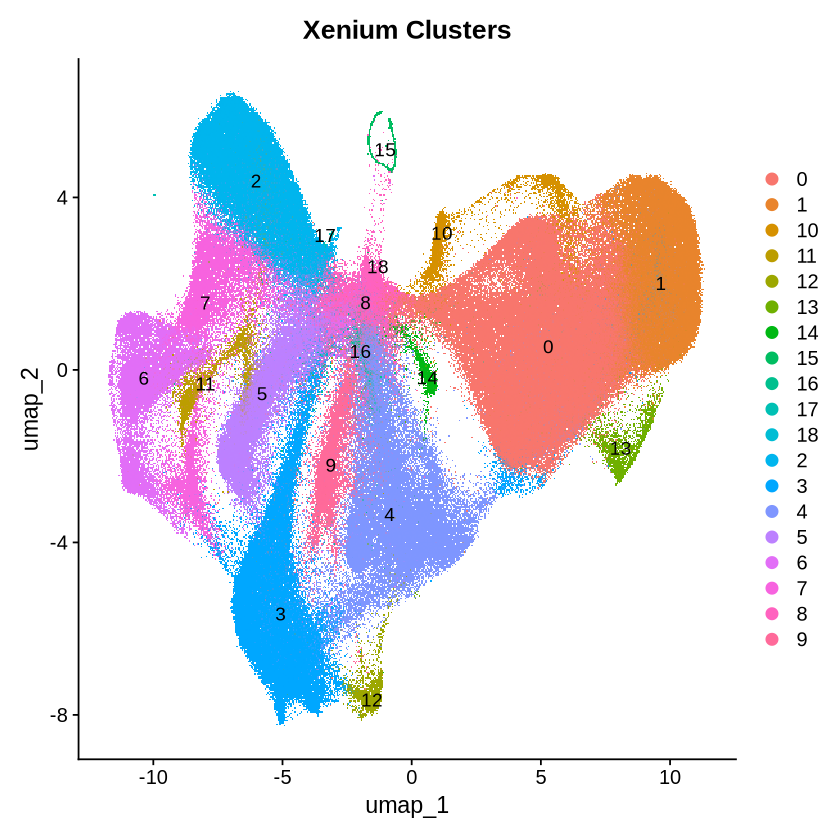


聚类统计:

     0      1     10     11     12     13     14     15     16     17     18 
115241  49668   5871   3918   2822   2407   2292   1413   1338     96      2 
     2      3      4      5      6      7      8      9 
 48217  44897  40881  27423  20900  16971  11536  10718 
✅ Xenium数据处理完成


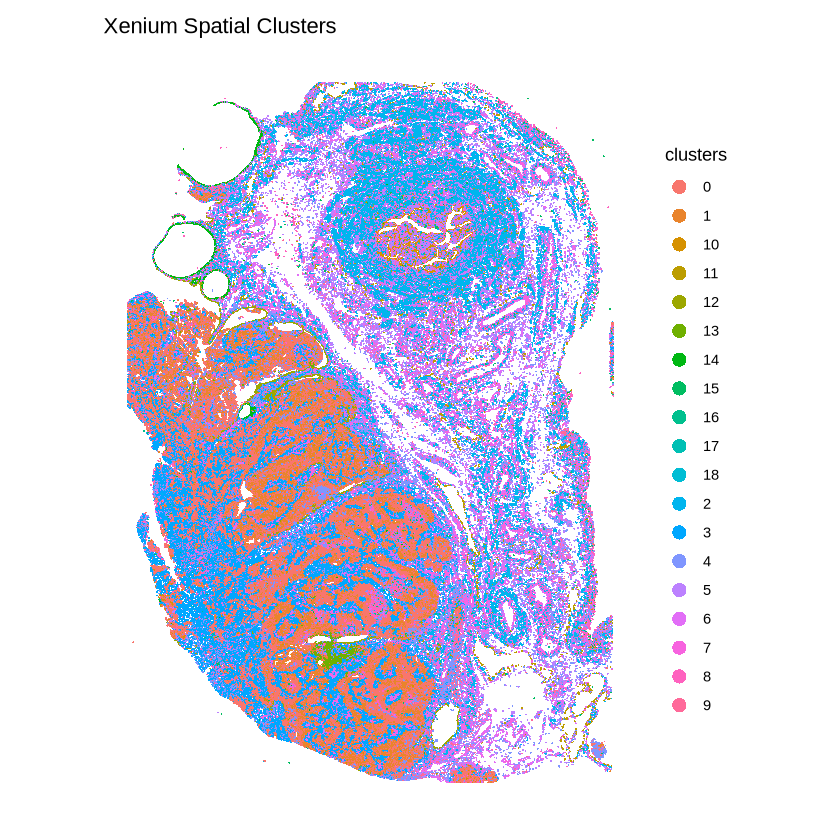

In [6]:
# ============================================
# Cell 6: Xenium数据降维和聚类
# ============================================

cat("🔧 处理Xenium数据（细胞数:", ncol(xenium.obj), "）\n")

DefaultAssay(xenium.obj) <- "Xenium"

xenium.obj <- NormalizeData(xenium.obj) %>%
              FindVariableFeatures() %>%
              ScaleData() %>%
              RunPCA(npcs = params$xenium_npcs, verbose = FALSE) %>%
              RunUMAP(dims = params$xenium_dims, verbose = FALSE) %>%
              FindNeighbors(reduction = "pca", dims = params$xenium_dims) %>%
              FindClusters(resolution = params$xenium_resolution, 
                          cluster.name = params$xenium_cluster_name)

# 可视化
p3 <- DimPlot(xenium.obj, group.by = params$xenium_cluster_name, label = TRUE) + 
      ggtitle("Xenium Clusters")
print(p3)

p4 <- ImageDimPlot(xenium.obj, fov = "fov", group.by = params$xenium_cluster_name, 
                   size = 0.5, dark.background = FALSE) +
      ggtitle("Xenium Spatial Clusters")
print(p4)

# 统计
cat("\n聚类统计:\n")
print(table(xenium.obj$clusters))

cat("✅ Xenium数据处理完成\n")

In [7]:
# ============================================
# Cell 7: 标签转移（优化版本）
# ============================================

# 检查是否已经完成标签转移
if (!"predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    cat("🏷️  开始优化标签转移...\n")
    
    # 1. 获取共同基因
    flex_xen_common_genes <- intersect(rownames(xenium.obj), rownames(flex_data.obj))
    cat("  共同基因数量:", length(flex_xen_common_genes), "\n")
    
    if (length(flex_xen_common_genes) < 100) {
        warning("共同基因数量较少（<100），标签转移效果可能不佳")
    }
    
    # 2. 创建Flex子集并优化预处理
    cat("  创建Flex子集并优化预处理...\n")
    flex_subset <- CreateSeuratObject(
        counts = flex_data.obj[["RNA"]]$counts[flex_xen_common_genes,],
        meta = flex_data.obj@meta.data
    ) %>%
        NormalizeData(normalization.method = "LogNormalize", scale.factor = 10000) %>%
        FindVariableFeatures(nfeatures = 3000) %>%  # 增加高变基因数
        ScaleData() %>%
        RunPCA(npcs = 50, verbose = FALSE)  # 增加PC数量
    
    # 3. 获取高变基因交集（用于锚点查找）
    flex_highvar <- VariableFeatures(flex_subset)
    xenium_highvar <- VariableFeatures(xenium.obj)
    common_highvar <- intersect(flex_highvar, xenium_highvar)
    
    # 4. 选择特征基因（优先使用高变基因，如果太少则使用所有共同基因）
    if (length(common_highvar) >= 200) {
        features_to_use <- common_highvar[1:min(2000, length(common_highvar))]
        cat("  使用高变基因数量:", length(features_to_use), "\n")
    } else {
        features_to_use <- flex_xen_common_genes
        cat("  使用所有共同基因:", length(features_to_use), "\n")
    }
    
    # 5. 将counts转回内存格式（加速计算）
    cat("  准备数据...\n")
    flex_data.obj[["RNA"]]$counts <- as(flex_data.obj[["RNA"]]$counts, "dgCMatrix")
    xenium.obj[["Xenium"]]$counts <- as(xenium.obj[["Xenium"]]$counts, "dgCMatrix")
    
    # 6. 寻找锚点（优化参数）
    cat("  寻找锚点（这可能需要一些时间）...\n")
    anchors_from_flex <- FindTransferAnchors(
        reference = flex_subset,
        query = xenium.obj,
        features = features_to_use,
        dims = params$transfer_dims,
        reference.reduction = "pca",
        reduction = "pcaproject",
        k.filter = NA,      # 使用所有锚点
        k.score = 30        # 增加k.score以提高锚点质量
    )
    
    cat("  找到", length(anchors_from_flex@anchors), "个锚点\n")
    
    # 7. 转移标签（优化参数）
    cat("  转移标签...\n")
    label_transfer <- TransferData(
        anchorset = anchors_from_flex,
        refdata = flex_subset$cell_type,
        dims = params$transfer_dims,
        weight.reduction = "pcaproject",  # 使用PCA投影
        l2.norm = TRUE,                   # L2归一化提高稳定性
        k.weight = 50                     # 调整权重计算的k值
    )
    
    # 8. 查看返回的数据结构
    cat("  TransferData 返回的列名:", paste(colnames(label_transfer), collapse = ", "), "\n")
    
    # 9. 添加预测结果
    xenium.obj <- AddMetaData(xenium.obj, metadata = label_transfer)
    
    # 10. 后处理：添加置信度筛选
    if ("prediction.score.max" %in% colnames(xenium.obj@meta.data)) {
        confidence_threshold <- 0.6
        xenium.obj@meta.data$predicted.id_filtered <- 
            ifelse(xenium.obj@meta.data$prediction.score.max > confidence_threshold,
                   as.character(xenium.obj@meta.data$predicted.id),
                   "low_confidence")
        cat("  高置信度预测阈值:", confidence_threshold, "\n")
        cat("  高置信度细胞数:", sum(xenium.obj@meta.data$prediction.score.max > confidence_threshold, na.rm = TRUE), "\n")
    }
    
    # 11. 创建完整标签列的别名
    if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
        xenium.obj@meta.data$predicted.id_full <- xenium.obj@meta.data$predicted.id
    }
    if ("prediction.score.max" %in% colnames(xenium.obj@meta.data)) {
        xenium.obj@meta.data$predicted.id_full.score <- xenium.obj@meta.data$prediction.score.max
    }
    
    cat("✅ 标签转移完成\n")
    cat("\n预测细胞类型分布:\n")
    print(table(xenium.obj$predicted.id))
    
    # 12. 显示预测分数统计
    if ("prediction.score.max" %in% colnames(xenium.obj@meta.data)) {
        cat("\n预测分数统计:\n")
        print(summary(xenium.obj$prediction.score.max))
        
        # 显示各细胞类型的平均置信度
        cat("\n各细胞类型平均置信度:\n")
        score_summary <- xenium.obj@meta.data %>%
            group_by(predicted.id) %>%
            summarise(
                mean_score = mean(prediction.score.max, na.rm = TRUE),
                median_score = median(prediction.score.max, na.rm = TRUE),
                n_cells = n()
            ) %>%
            arrange(desc(mean_score))
        print(score_summary)
    }
    
    # 13. 可选：释放内存
    gc()
    
} else {
    cat("✅ 标签转移结果已存在，跳过\n")
    cat("当前预测相关列:", 
        paste(grep("predicted", colnames(xenium.obj@meta.data), value = TRUE), collapse = ", "), "\n")
}

🏷️  开始优化标签转移...
  共同基因数量: 4912 
  创建Flex子集并优化预处理...


Normalizing layer: counts

Finding variable features for layer counts



  使用高变基因数量: 1637 
  准备数据...
  寻找锚点（这可能需要一些时间）...


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 32793 anchors



  找到 98379 个锚点
  转移标签...


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights

Predicting cell labels



  TransferData 返回的列名: predicted.id, prediction.score.Tumor.Associated.Fibroblasts, prediction.score.Endothelial.Cells, prediction.score.Stromal.Associated.Fibroblasts, prediction.score.T...NK.Cells, prediction.score.Malignant.Cells.Lining.Cyst, prediction.score.Proliferative.Tumor.Cells, prediction.score.Tumor.Cells, prediction.score.Pericytes, prediction.score.Granulosa.Cells, prediction.score.Macrophages, prediction.score.Smooth.Muscle.Cells, prediction.score.VEGFA..Tumor.Cells, prediction.score.MT.High..Jun..Fos..Tumor.Cells, prediction.score.Fallopian.Tube.Epithelium, prediction.score.Inflammatory.Tumor.Cells, prediction.score.Ciliated.Epithelial.Cells, prediction.score.max 
  高置信度预测阈值: 0.6 
  高置信度细胞数: 321851 
✅ 标签转移完成

预测细胞类型分布:

     Ciliated Epithelial Cells              Endothelial Cells 
                          3451                          22071 
     Fallopian Tube Epithelium                Granulosa Cells 
                          6734                           2298 
   

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,6184385,330.3,14099124,753.0,14099124,753.0
Vcells,322283249,2458.9,743915862,5675.7,730787461,5575.5


📊 绘制预测结果...


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



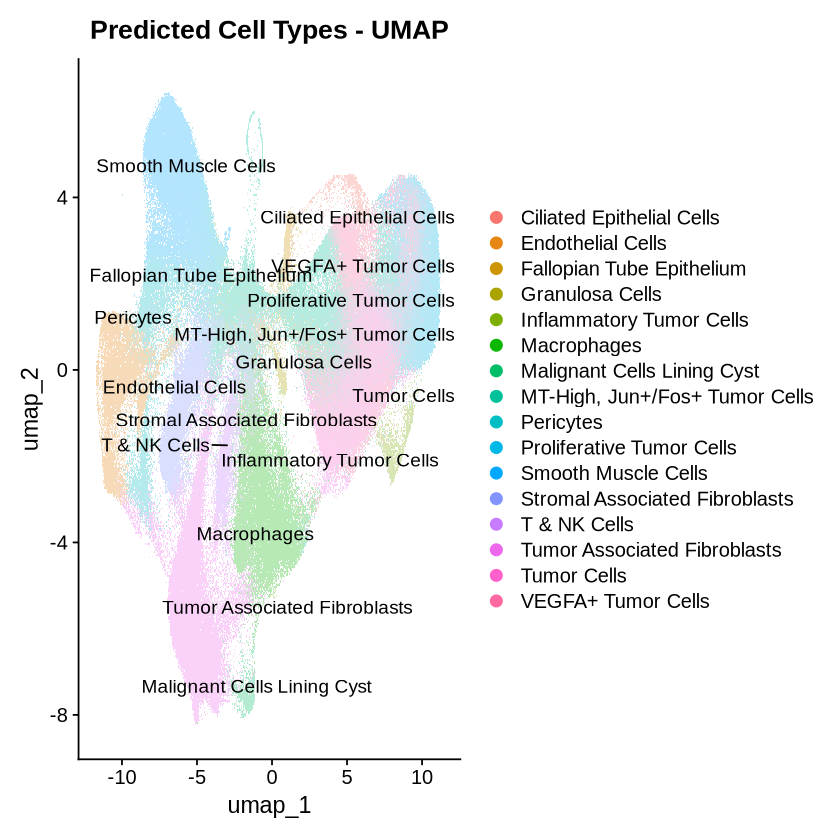


📈 预测分数分析...
  找到 17 个预测分数列
  预测分数统计:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.19    0.69    0.91    0.83    1.00    1.00   99627 


Warning message:
“There were 6 warnings in `summarise()`.
The first warning was:
ℹ In argument: `min_score = min(prediction_score, na.rm = TRUE)`.
ℹ In group 6: `predicted.id = "MT-High, Jun+/Fos+ Tumor Cells"`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 5 remaining warnings.”



📊 按细胞类型的预测分数统计:
# A tibble: 16 × 6
   predicted.id              mean_score median_score min_score max_score n_cells
   <chr>                          <dbl>        <dbl>     <dbl>     <dbl>   <int>
 1 Endothelial Cells              0.943        1         0.218         1   22071
 2 Granulosa Cells                0.877        1         0.225         1    2298
 3 Macrophages                    0.920        1         0.217         1   32368
 4 Tumor Associated Fibrobl…      0.948        1         0.209         1   50487
 5 Stromal Associated Fibro…      0.842        0.922     0.190         1   25010
 6 Inflammatory Tumor Cells       0.829        0.895     0.222         1    2650
 7 Smooth Muscle Cells            0.825        0.880     0.216         1   47557
 8 Ciliated Epithelial Cells      0.805        0.872     0.247         1    3451
 9 Malignant Cells Lining C…      0.803        0.863     0.227         1    2673
10 Proliferative Tumor Cells      0.761        0.783     0.232         1 

Warning message:
“Removed 99627 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 99627 rows containing non-finite outside the scale range
(`stat_summary()`).”


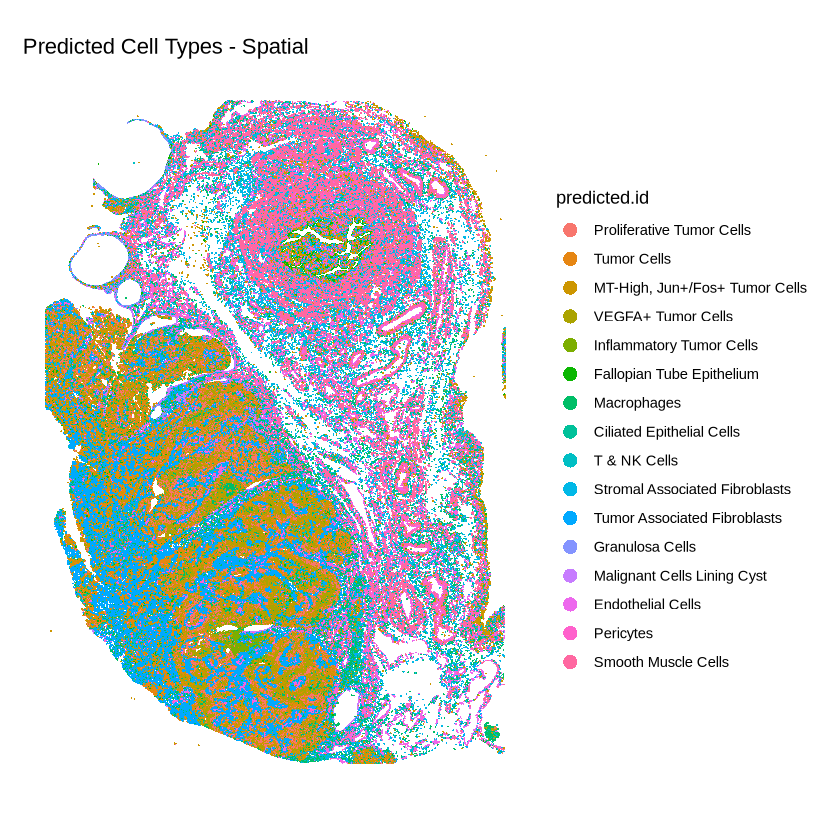

Warning message:
“Removed 99627 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


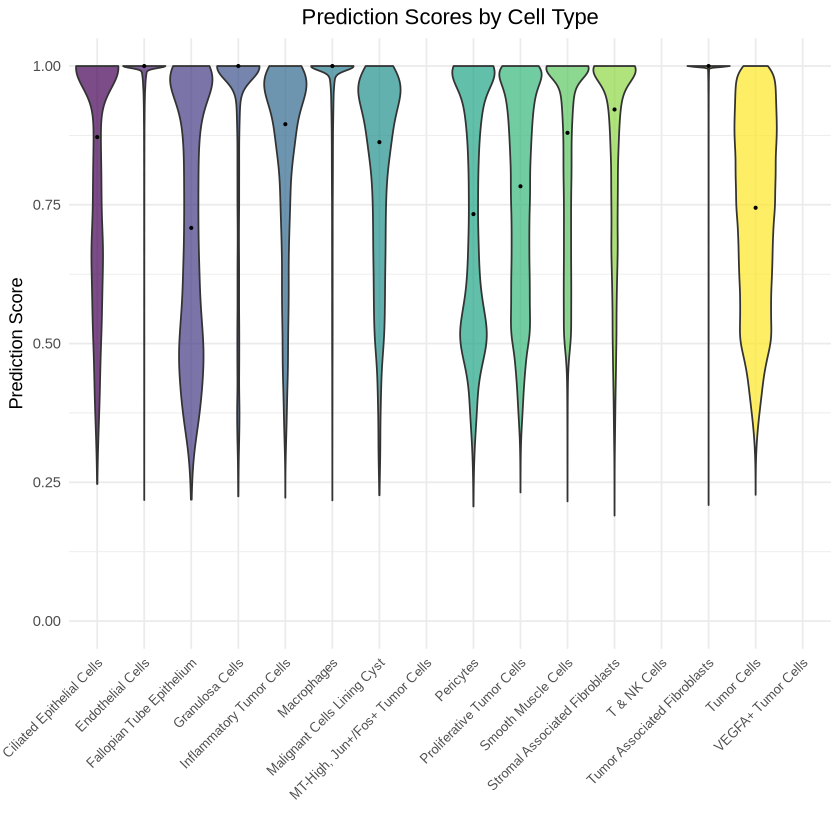


⚠️ 预测分数 < 0.5 的细胞数量: 21894 (5.4%)

✅ 可视化完成


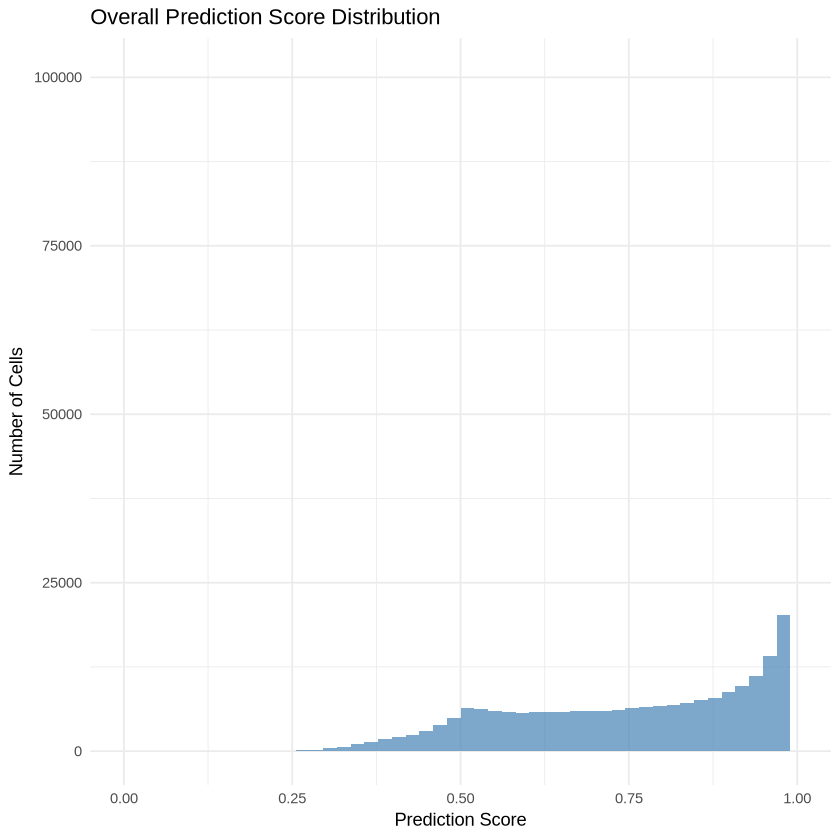

In [8]:
# ============================================
# Cell 8: 可视化标签转移结果
# ============================================

if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
    cat("📊 绘制预测结果...\n")
    
    # 1. UMAP可视化
    p5 <- DimPlot(xenium.obj, reduction = "umap", group.by = "predicted.id", 
                  label = TRUE, pt.size = 0.3, repel = TRUE) + 
          ggtitle("Predicted Cell Types - UMAP")
    print(p5)
    
    # 2. 空间可视化
    p6 <- tryCatch({
        ImageDimPlot(xenium.obj, fov = "fov", group.by = "predicted.id", 
                     size = 0.5, dark.background = FALSE) +
            ggtitle("Predicted Cell Types - Spatial")
    }, error = function(e) {
        cat("    空间可视化失败:", e$message, "\n")
        return(NULL)
    })
    if (!is.null(p6)) print(p6)
    
    # 3. 预测分数处理
    # 找出所有预测分数列（格式：prediction.score.xxx）
    score_cols <- grep("prediction\\.score\\.", colnames(xenium.obj@meta.data), value = TRUE)
    
    if (length(score_cols) > 0) {
        cat("\n📈 预测分数分析...\n")
        cat("  找到", length(score_cols), "个预测分数列\n")
        
        # 为每个细胞找到其预测类型的分数（最大分数）
        # 方法：对于每个细胞，从对应的预测类型列中提取分数
        get_max_score <- function(row) {
            cell_type <- row["predicted.id"]
            score_col <- paste0("prediction.score.", gsub(" ", ".", cell_type))
            if (score_col %in% names(row)) {
                return(as.numeric(row[score_col]))
            } else {
                return(NA)
            }
        }
        
        # 计算每个细胞的预测分数（其预测类型的分数）
        xenium.obj@meta.data$prediction_score <- apply(
            xenium.obj@meta.data, 1, get_max_score
        )
        
        cat("  预测分数统计:\n")
        print(summary(xenium.obj@meta.data$prediction_score))
        
        # 按细胞类型统计分数
        score_stats <- xenium.obj@meta.data %>%
            group_by(predicted.id) %>%
            summarise(
                mean_score = mean(prediction_score, na.rm = TRUE),
                median_score = median(prediction_score, na.rm = TRUE),
                min_score = min(prediction_score, na.rm = TRUE),
                max_score = max(prediction_score, na.rm = TRUE),
                n_cells = n()
            ) %>%
            arrange(desc(median_score))
        
        cat("\n📊 按细胞类型的预测分数统计:\n")
        print(score_stats)
        
        # 绘制小提琴图
        p7 <- ggplot(xenium.obj@meta.data, 
                     aes(x = predicted.id, y = prediction_score, fill = predicted.id)) +
            geom_violin(scale = "width", trim = TRUE) +
            stat_summary(fun = median, geom = "point", size = 0.5, color = "black") +
            scale_fill_viridis_d(alpha = 0.7) +
            theme_minimal() +
            theme(legend.position = "none",
                  axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
                  plot.title = element_text(hjust = 0.5)) +
            ggtitle("Prediction Scores by Cell Type") +
            xlab("") + ylab("Prediction Score") +
            ylim(0, 1)
        print(p7)
        
        # 总体分数分布直方图
        p8 <- ggplot(xenium.obj@meta.data, aes(x = prediction_score)) +
            geom_histogram(bins = 50, fill = "steelblue", alpha = 0.7) +
            theme_minimal() +
            ggtitle("Overall Prediction Score Distribution") +
            xlab("Prediction Score") + ylab("Number of Cells") +
            xlim(0, 1)
        print(p8)
        
        # 可选：显示低质量预测的细胞（分数 < 0.5）
        low_score_cells <- sum(xenium.obj@meta.data$prediction_score < 0.5, na.rm = TRUE)
        cat(sprintf("\n⚠️ 预测分数 < 0.5 的细胞数量: %d (%.1f%%)\n", 
                    low_score_cells, low_score_cells / ncol(xenium.obj) * 100))
        
    } else {
        cat("\n⚠️ 未找到预测分数列，跳过分数分布图\n")
        cat("  当前元数据列名中包含 'score' 的:\n")
        score_cols_found <- grep("score", colnames(xenium.obj@meta.data), value = TRUE, ignore.case = TRUE)
        print(score_cols_found)
    }
    
    cat("\n✅ 可视化完成\n")
    
} else {
    cat("⚠️ 未找到预测结果，请先运行Cell 7\n")
}

In [9]:
# # ============================================
# # Cell 9：导出结果（映射版） 与 Python 数据导出
# # ============================================

# # 首先定义输出路径（如果尚未定义）
# if (!exists("paths") || !"output_gnn_csv" %in% names(paths)) {
#     paths$output_gnn_csv <- "./data/xenium_for_gnn.csv"
#     cat("📁 已添加 GNN 输出路径:", paths$output_gnn_csv, "\n")
# }

# if ("predicted.id" %in% colnames(xenium.obj@meta.data)) {
    
#     cat("📤 开始统一导出...\n")
    
#     # ------------------------------
#     # 1. 准备基础数据
#     # ------------------------------
    
#     # 元数据（含预测标签、聚类等）
#     meta <- xenium.obj@meta.data %>% 
#         rownames_to_column(var = "cell_id")
    
#     # 确保 predicted_cell_type 列存在
#     if (!"predicted_cell_type" %in% colnames(meta) && "predicted.id" %in% colnames(meta)) {
#         meta$predicted_cell_type <- meta$predicted.id
#         cat("  ✅ 已添加 predicted_cell_type 列\n")
#     }
    
#     # 空间坐标（Xenium 默认列名 x_centroid, y_centroid）
#     coords <- GetTissueCoordinates(xenium.obj, scale = NULL)
#     coords$cell_id <- rownames(coords)
    
#     # PCA 嵌入（前 50 维）
#     pca_emb <- Embeddings(xenium.obj, reduction = "pca") %>% 
#         as.data.frame() %>% 
#         rownames_to_column("cell_id")
    
#     # 合并所有信息
#     export_df <- meta %>%
#         left_join(coords, by = "cell_id") %>%
#         left_join(pca_emb, by = "cell_id")
    
#     # 添加聚类列（如果尚未添加）
#     if (params$xenium_cluster_name %in% colnames(export_df)) {
#         export_df$cluster <- export_df[[params$xenium_cluster_name]]
#     }
    
#     cat("  ✅ 基础数据合并完成，共", nrow(export_df), "个细胞\n")
    
#     # ------------------------------
#     # 2. 处理预测分数与一致性（沿用原映射表逻辑）
#     # ------------------------------
    
#     score_cols <- grep("prediction\\.score\\.", colnames(export_df), value = TRUE)
    
#     if (length(score_cols) > 0) {
#         cat("  找到", length(score_cols), "个预测分数列\n")
        
#         # 方法1：计算预测分数（使用映射表）
#         get_prediction_score_mapped <- function(row) {
#             cell_type <- row["predicted_cell_type"]
#             if (!is.na(cell_type) && cell_type != "") {
#                 if (cell_type %in% names(reverse_mapping)) {
#                     score_col <- paste0("prediction.score.", reverse_mapping[cell_type])
#                     if (score_col %in% names(row)) {
#                         return(as.numeric(row[score_col]))
#                     }
#                 }
#             }
#             return(NA_real_)
#         }
        
#         cat("  正在计算预测分数...\n")
#         export_df$prediction_score <- apply(export_df, 1, get_prediction_score_mapped)
        
#         # 方法2：最高分类型（使用映射表）
#         get_max_score_type_mapped <- function(row) {
#             scores <- as.numeric(row[score_cols])
#             if (all(is.na(scores))) return(NA)
#             max_idx <- which.max(scores)
#             if (length(max_idx) > 0) {
#                 max_type_key <- gsub("prediction.score.", "", score_cols[max_idx])
#                 # 使用映射表转换为原始格式
#                 if (max_type_key %in% names(cell_type_mapping)) {
#                     return(cell_type_mapping[max_type_key])
#                 } else {
#                     # 后备方案：尝试自动转换
#                     converted <- max_type_key %>%
#                         gsub("\\.\\.", ", ", .) %>%
#                         gsub("\\.", " ", .)
#                     return(converted)
#                 }
#             }
#             return(NA)
#         }
        
#         cat("  正在计算最高分类型...\n")
#         export_df$max_score_type <- apply(export_df, 1, get_max_score_type_mapped)
        
#         # 一致性检查（确保两个列都存在）
#         if ("predicted_cell_type" %in% colnames(export_df) && 
#             "max_score_type" %in% colnames(export_df)) {
#             export_df$prediction_consistent <- export_df$predicted_cell_type == export_df$max_score_type
#             consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
#             cat("  预测一致性: ", consistent_count, "/", nrow(export_df), 
#                 " (", round(consistent_count / nrow(export_df) * 100, 1), "%)\n", sep = "")
            
#             # 可选：打印不一致摘要
#             if (consistent_count < nrow(export_df)) {
#                 inconsistent_df <- export_df[!export_df$prediction_consistent & !is.na(export_df$prediction_consistent), ]
#                 cat("\n⚠️ 发现", nrow(inconsistent_df), "个不一致的细胞\n")
#             }
#         } else {
#             cat("  ⚠️ 缺少必要列，跳过一致性检查\n")
#         }
        
#         # 统计有效分数
#         valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
#         cat("  有效分数细胞数:", length(valid_scores), "/", nrow(export_df), 
#             " (", round(length(valid_scores)/nrow(export_df)*100, 1), "%)\n", sep = "")
        
#         cat("  预测分数统计:\n")
#         print(summary(valid_scores))
        
#     } else {
#         cat("  ⚠️ 未找到预测分数列\n")
#     }
    
#     # ------------------------------
#     # 3. 导出基础预测结果 CSV（cell_groups.csv）
#     # ------------------------------
    
#     base_cols <- c("cell_id", "cluster", "predicted_cell_type", 
#                    "prediction_score", "max_score_type", "prediction_consistent")
#     base_cols <- base_cols[base_cols %in% colnames(export_df)]
#     cell_groups <- export_df %>% select(all_of(base_cols))
    
#     write.csv(cell_groups, paths$output_csv, row.names = FALSE)
#     cat("\n✅ 基础结果已导出:", paths$output_csv, "\n")
#     cat("  导出列数:", ncol(cell_groups), "\n")
#     cat("  导出细胞数:", nrow(cell_groups), "\n")
    
#     # 显示预览
#     cat("\n📊 文件预览（前10行）:\n")
#     print(head(cell_groups, 10))
    
#     # ------------------------------
#     # 4. 导出完整预测分数 CSV（cell_predictions_full.csv）
#     # ------------------------------
    
#     if (length(score_cols) > 0) {
#         full_export <- export_df %>%
#             select(cell_id, predicted_cell_type, prediction_score, 
#                    max_score_type, prediction_consistent, all_of(score_cols))
        
#         write.csv(full_export, paths$output_full_csv, row.names = FALSE)
#         cat("✅ 完整预测分数文件已导出:", paths$output_full_csv, "\n")
#     }
    
#     # ------------------------------
#     # 5. 导出 GNN 专用 CSV（xenium_for_gnn.csv）
#     # ------------------------------
    
#     # 选择 PCA 列（通常是 PC_1, PC_2, ...）
#     pca_cols <- grep("^PC_", colnames(export_df), value = TRUE)
    
#     # 如果没找到 PC_ 格式，尝试其他常见格式
#     if (length(pca_cols) == 0) {
#         pca_cols <- grep("^pca$|^PC$|^dim", colnames(export_df), value = TRUE, ignore.case = TRUE)
#     }
    
#     if (length(pca_cols) > 0) {
#         # 限制 PCA 维度，避免文件过大（最多 50 维）
#         if (length(pca_cols) > 50) {
#             pca_cols <- pca_cols[1:50]
#             cat("  限制 PCA 维度为前 50 维\n")
#         }
        
#         # 确定坐标列名
#         coord_x <- ifelse("x_centroid" %in% colnames(export_df), "x_centroid", 
#                          ifelse("x" %in% colnames(export_df), "x", NA))
#         coord_y <- ifelse("y_centroid" %in% colnames(export_df), "y_centroid", 
#                          ifelse("y" %in% colnames(export_df), "y", NA))
        
#         if (!is.na(coord_x) && !is.na(coord_y)) {
#             # 保留需要的列：cell_id, 坐标, 预测标签, PCA 特征
#             gnn_cols <- c("cell_id", coord_x, coord_y, "predicted_cell_type", pca_cols)
#             gnn_cols <- gnn_cols[gnn_cols %in% colnames(export_df)]
#             gnn_data <- export_df %>% select(all_of(gnn_cols))
            
#             # 标准化坐标列名
#             if (coord_x != "x_centroid") {
#                 colnames(gnn_data)[colnames(gnn_data) == coord_x] <- "x_centroid"
#             }
#             if (coord_y != "y_centroid") {
#                 colnames(gnn_data)[colnames(gnn_data) == coord_y] <- "y_centroid"
#             }
            
#             write.csv(gnn_data, paths$output_gnn_csv, row.names = FALSE)
#             cat("✅ GNN 专用数据已导出:", paths$output_gnn_csv, "\n")
#             cat("  包含", nrow(gnn_data), "个细胞，", ncol(gnn_data)-4, "个 PCA 特征\n")
#         } else {
#             cat("⚠️ 未找到空间坐标列，跳过 GNN 专用数据导出\n")
#         }
#     } else {
#         cat("⚠️ 未找到 PCA 特征列，跳过 GNN 专用数据导出\n")
#         cat("  提示：如果已计算 PCA，列名应为 'PC_1', 'PC_2' 等格式\n")
#         cat("  当前列名示例:", paste(head(colnames(export_df), 10), collapse = ", "), "\n")
#     }
    
#     # ------------------------------
#     # 6. 保存完整 Seurat 对象
#     # ------------------------------
    
#     saveRDS(xenium.obj, paths$output_rds)
#     cat("✅ 完整 Seurat 对象已保存:", paths$output_rds, "\n")
    
#     # ------------------------------
#     # 7. 保存 Flex 参考对象（可选）
#     # ------------------------------
    
#     if (params$save_intermediate && exists("flex_data.obj")) {
#         saveRDS(flex_data.obj, paths$output_flex_rds)
#         cat("✅ Flex 参考对象已保存:", paths$output_flex_rds, "\n")
#     }
    
#     # ------------------------------
#     # 8. 生成详细统计报告
#     # ------------------------------
    
#     cat("\n", paste(rep("━", 60), collapse = ""), "\n")
#     cat("📊 生成统计报告...\n")
#     cat(paste(rep("━", 60), collapse = ""), "\n")
    
#     # 确保统计报告目录存在
#     stats_dir <- dirname(paths$output_stats)
#     if (!dir.exists(stats_dir)) {
#         dir.create(stats_dir, recursive = TRUE)
#     }
    
#     sink(paths$output_stats)
    
#     cat("预测结果统计报告\n")
#     cat("生成时间:", Sys.time(), "\n")
#     cat("总细胞数:", nrow(export_df), "\n")
#     cat(paste(rep("=", 60), collapse = ""), "\n\n")
    
#     # 1. 细胞类型分布
#     if ("predicted_cell_type" %in% colnames(export_df)) {
#         cat("📈 1. 预测细胞类型分布\n")
#         cat(paste(rep("-", 40), collapse = ""), "\n")
#         type_counts <- sort(table(export_df$predicted_cell_type), decreasing = TRUE)
#         print(type_counts)
#     }
    
#     # 2. 预测分数统计
#     if ("prediction_score" %in% colnames(export_df)) {
#         valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
#         if (length(valid_scores) > 0) {
#             cat("\n📈 2. 预测分数统计（有效分数: N=", length(valid_scores), "）\n", sep = "")
#             cat(paste(rep("-", 40), collapse = ""), "\n")
#             print(summary(valid_scores))
            
#             cat("\n📈 3. 按细胞类型的预测分数统计\n")
#             cat(paste(rep("-", 40), collapse = ""), "\n")
#             score_by_type <- export_df %>%
#                 filter(!is.na(prediction_score)) %>%
#                 group_by(predicted_cell_type) %>%
#                 summarise(
#                     n_cells = n(),
#                     mean_score = mean(prediction_score, na.rm = TRUE),
#                     median_score = median(prediction_score, na.rm = TRUE),
#                     sd_score = sd(prediction_score, na.rm = TRUE),
#                     min_score = min(prediction_score, na.rm = TRUE),
#                     max_score = max(prediction_score, na.rm = TRUE),
#                     .groups = 'drop'
#                 ) %>%
#                 arrange(desc(mean_score))
#             print(score_by_type)
#         }
#     }
    
#     # 3. 一致性统计
#     if ("prediction_consistent" %in% colnames(export_df)) {
#         cat("\n📈 4. 预测一致性统计\n")
#         cat(paste(rep("-", 40), collapse = ""), "\n")
#         consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
#         total_valid <- sum(!is.na(export_df$prediction_consistent))
#         if (total_valid > 0) {
#             cat("  一致细胞数: ", consistent_count, "\n")
#             cat("  不一致细胞数: ", total_valid - consistent_count, "\n")
#             cat("  一致率: ", round(consistent_count / total_valid * 100, 2), "%\n", sep = "")
            
#             cat("\n📈 5. 按细胞类型的一致性统计\n")
#             cat(paste(rep("-", 40), collapse = ""), "\n")
#             consistency_by_type <- export_df %>%
#                 filter(!is.na(prediction_consistent)) %>%
#                 group_by(predicted_cell_type) %>%
#                 summarise(
#                     n_cells = n(),
#                     consistent = sum(prediction_consistent, na.rm = TRUE),
#                     consistency_rate = consistent / n() * 100,
#                     .groups = 'drop'
#                 ) %>%
#                 arrange(desc(consistency_rate))
#             print(consistency_by_type)
            
#             # 不一致案例
#             inconsistent_cases <- export_df %>%
#                 filter(!prediction_consistent & !is.na(prediction_consistent)) %>%
#                 select(cell_id, predicted_cell_type, max_score_type, prediction_score) %>%
#                 head(20)
            
#             if (nrow(inconsistent_cases) > 0) {
#                 cat("\n📈 6. 不一致案例示例（前20个）\n")
#                 cat(paste(rep("-", 40), collapse = ""), "\n")
#                 print(inconsistent_cases)
#             }
#         }
#     }
    
#     sink()
    
#     cat("\n✅ 详细统计报告已保存:", paths$output_stats, "\n")
    
#     # 控制台摘要
#     cat("\n", paste(rep("━", 60), collapse = ""), "\n")
#     cat("📊 导出完成摘要\n")
#     cat(paste(rep("━", 60), collapse = ""), "\n")
#     cat("  总细胞数:", nrow(export_df), "\n")
#     if (exists("valid_scores") && length(valid_scores) > 0) {
#         cat("  有效分数细胞数:", length(valid_scores), "\n")
#     }
#     if (exists("consistent_count") && exists("total_valid") && total_valid > 0) {
#         cat("  预测一致性: ", round(consistent_count / total_valid * 100, 1), "%\n", sep = "")
#     }
#     cat("  输出文件:\n")
#     cat("    -", paths$output_csv, "\n")
#     cat("    -", paths$output_full_csv, "\n")
#     if (file.exists(paths$output_gnn_csv)) {
#         cat("    -", paths$output_gnn_csv, "\n")
#     }
#     cat("    -", paths$output_rds, "\n")
#     cat("    -", paths$output_stats, "\n")
#     cat(paste(rep("━", 60), collapse = ""), "\n")
#     cat("✅ 所有导出任务完成\n")
    
# } else {
#     cat("⚠️ 未找到预测结果，请先运行 Cell 7 完成标签转移\n")
# }

In [18]:
# ============================================
# Cell 9.1: 检查坐标信息并修复
# ============================================

cat("🔍 检查坐标信息...\n")

# 检查 Xenium 对象中的坐标可用性
cat("\n1. 检查 GetTissueCoordinates 结果:\n")
coords_check <- tryCatch({
    GetTissueCoordinates(xenium.obj, scale = NULL)
}, error = function(e) {
    cat("  错误:", e$message, "\n")
    return(NULL)
})

if (!is.null(coords_check) && nrow(coords_check) > 0) {
    cat("  ✅ GetTissueCoordinates 返回", nrow(coords_check), "个坐标\n")
    print(head(coords_check))
} else {
    cat("  ⚠️ GetTissueCoordinates 未返回有效坐标\n")
}

# 检查元数据中的坐标列
cat("\n2. 检查元数据中的坐标列:\n")
coord_cols <- grep("x_centroid|y_centroid|cell_center_x|cell_center_y|x$|y$", 
                   colnames(xenium.obj@meta.data), 
                   value = TRUE, 
                   ignore.case = TRUE)
if (length(coord_cols) > 0) {
    cat("  找到可能的坐标列:\n")
    print(coord_cols)
} else {
    cat("  ⚠️ 元数据中未找到坐标列\n")
}

# 检查 Images 中的坐标信息
cat("\n3. 检查 Images 中的坐标信息:\n")
if (length(xenium.obj@images) > 0) {
    cat("  找到", length(xenium.obj@images), "个图像对象\n")
    for (img_name in names(xenium.obj@images)) {
        img <- xenium.obj@images[[img_name]]
        if ("centroids" %in% names(img@molecules)) {
            cat("  ✅ 在", img_name, "中找到 centroids\n")
        }
    }
} else {
    cat("  ⚠️ 未找到图像对象\n")
}

# 修复坐标：从不同来源提取坐标
cat("\n4. 尝试提取坐标...\n")

# 方法1: 从 GetTissueCoordinates 获取
if (!is.null(coords_check) && nrow(coords_check) > 0) {
    coords_df <- coords_check %>%
        rownames_to_column("cell_id")
    colnames(coords_df)[colnames(coords_df) == "x"] <- "x_centroid"
    colnames(coords_df)[colnames(coords_df) == "y"] <- "y_centroid"
    cat("  ✅ 方法1成功: GetTissueCoordinates\n")
    
# 方法2: 从元数据中提取
} else if (length(coord_cols) >= 2) {
    x_col <- coord_cols[grepl("x", coord_cols, ignore.case = TRUE)][1]
    y_col <- coord_cols[grepl("y", coord_cols, ignore.case = TRUE)][1]
    
    coords_df <- data.frame(
        cell_id = rownames(xenium.obj@meta.data),
        x_centroid = xenium.obj@meta.data[[x_col]],
        y_centroid = xenium.obj@meta.data[[y_col]]
    )
    cat("  ✅ 方法2成功: 从元数据提取 (", x_col, ", ", y_col, ")\n")
    
# 方法3: 从 Images 中提取
} else if (length(xenium.obj@images) > 0) {
    img_name <- names(xenium.obj@images)[1]
    img <- xenium.obj@images[[img_name]]
    
    if ("centroids" %in% names(img@molecules)) {
        centroids <- img@molecules$centroids
        coords_df <- data.frame(
            cell_id = rownames(centroids),
            x_centroid = centroids$x,
            y_centroid = centroids$y
        )
        cat("  ✅ 方法3成功: 从 Images 提取\n")
    } else {
        stop("❌ 所有方法都无法获取坐标信息")
    }
} else {
    stop("❌ 无法找到任何坐标信息")
}

# 验证坐标
cat("\n5. 验证坐标数据:\n")
cat("  坐标数量:", nrow(coords_df), "\n")
cat("  坐标预览:\n")
print(head(coords_df))
cat("\n  坐标缺失情况:\n")
cat("    x_centroid 缺失:", sum(is.na(coords_df$x_centroid)), "\n")
cat("    y_centroid 缺失:", sum(is.na(coords_df$y_centroid)), "\n")

# 保存修复后的坐标到元数据
xenium.obj@meta.data$x_centroid <- coords_df$x_centroid[match(rownames(xenium.obj@meta.data), coords_df$cell_id)]
xenium.obj@meta.data$y_centroid <- coords_df$y_centroid[match(rownames(xenium.obj@meta.data), coords_df$cell_id)]

cat("\n✅ 坐标修复完成，已保存到元数据\n")

🔍 检查坐标信息...

1. 检查 GetTissueCoordinates 结果:
  ✅ GetTissueCoordinates 返回 406611 个坐标
         x        y       cell
1 540.8646 4230.247 aaaaebmm-1
2 532.8607 4242.920 aaaafhpp-1
3 527.6399 4240.649 aaaahcem-1
4 534.3693 4234.183 aaaakeoi-1
5 527.5938 4232.857 aaaalald-1
6 554.5443 4277.600 aaaalomf-1

2. 检查元数据中的坐标列:
  找到可能的坐标列:
[1] "prediction.score.max" "x_centroid"           "y_centroid"          

3. 检查 Images 中的坐标信息:
  找到 1 个图像对象

4. 尝试提取坐标...
  ✅ 方法1成功: GetTissueCoordinates

5. 验证坐标数据:
  坐标数量: 406611 
  坐标预览:
  cell_id x_centroid y_centroid       cell
1       1   540.8646   4230.247 aaaaebmm-1
2       2   532.8607   4242.920 aaaafhpp-1
3       3   527.6399   4240.649 aaaahcem-1
4       4   534.3693   4234.183 aaaakeoi-1
5       5   527.5938   4232.857 aaaalald-1
6       6   554.5443   4277.600 aaaalomf-1

  坐标缺失情况:
    x_centroid 缺失: 0 
    y_centroid 缺失: 0 

✅ 坐标修复完成，已保存到元数据


In [19]:
# ============================================
# Cell 9.2: 准备导出数据的基础结构（修复版）
# ============================================

cat("📦 准备导出数据的基础结构...\n")

# 检查预测结果是否存在
if (!"predicted.id" %in% colnames(xenium.obj@meta.data)) {
    stop("⚠️ 未找到预测结果，请先运行 Cell 7 完成标签转移")
}

# 1. 准备元数据
cat("\n1. 准备元数据...\n")
meta <- xenium.obj@meta.data %>% 
    rownames_to_column(var = "cell_id")

# 确保 predicted_cell_type 列存在
if (!"predicted_cell_type" %in% colnames(meta) && "predicted.id" %in% colnames(meta)) {
    meta$predicted_cell_type <- meta$predicted.id
    cat("  ✅ 已添加 predicted_cell_type 列\n")
}

# 2. 准备坐标数据（关键修复）
cat("\n2. 准备坐标数据...\n")

# 方法1: 使用 GetTissueCoordinates 直接获取坐标
coords_raw <- GetTissueCoordinates(xenium.obj, scale = NULL)
cat("  GetTissueCoordinates 返回:", nrow(coords_raw), "个坐标\n")

# 将坐标转换为数据框，确保 cell_id 正确匹配
if (nrow(coords_raw) > 0) {
    coords_df <- coords_raw %>%
        rownames_to_column("cell_id") %>%
        rename(x_centroid = x, y_centroid = y)
    
    cat("  坐标数据框预览:\n")
    print(head(coords_df))
    
    # 检查匹配情况
    meta_cells <- meta$cell_id
    coord_cells <- coords_df$cell_id
    
    cat("\n  匹配检查:\n")
    cat("    元数据细胞数:", length(meta_cells), "\n")
    cat("    坐标细胞数:", length(coord_cells), "\n")
    
    common_cells <- intersect(meta_cells, coord_cells)
    cat("    共同细胞数:", length(common_cells), "\n")
    
    if (length(common_cells) == 0) {
        cat("  ⚠️ 警告: cell_id 格式不匹配！\n")
        cat("    元数据示例:", head(meta_cells, 3), "\n")
        cat("    坐标示例:", head(coord_cells, 3), "\n")
        
        # 尝试修复 cell_id 格式
        # 有时 rownames 可能包含额外的信息
        if (all(grepl("^[a-z]+-[0-9]+$", coord_cells))) {
            # 坐标的 cell_id 格式正确，元数据可能包含其他内容
            # 尝试从元数据的 rownames 提取
            meta$cell_id_simple <- rownames(xenium.obj@meta.data)
            common_cells <- intersect(meta$cell_id_simple, coord_cells)
            if (length(common_cells) > 0) {
                cat("    使用简化 cell_id 匹配成功！\n")
                meta$cell_id <- meta$cell_id_simple
            }
        }
    }
} else {
    stop("❌ 无法获取坐标数据")
}

# 3. 合并坐标到元数据
cat("\n3. 合并坐标到元数据...\n")
# 确保 cell_id 列类型一致
meta$cell_id <- as.character(meta$cell_id)
coords_df$cell_id <- as.character(coords_df$cell_id)

# 执行合并
export_df <- meta %>%
    left_join(coords_df, by = "cell_id", suffix = c("", "_coord"))

# 检查合并结果
if ("x_centroid" %in% colnames(export_df)) {
    valid_coords <- !is.na(export_df$x_centroid) & !is.na(export_df$y_centroid)
    cat("  合并后有效坐标数:", sum(valid_coords), "/", nrow(export_df), "\n")
    
    if (sum(valid_coords) == 0) {
        cat("  ⚠️ 警告: 合并后坐标全为 NA，尝试其他匹配方式...\n")
        
        # 尝试使用行名匹配
        coords_df$rowname <- rownames(xenium.obj@meta.data)[match(coords_df$cell_id, rownames(xenium.obj@meta.data))]
        if (!all(is.na(coords_df$rowname))) {
            export_df <- meta %>%
                left_join(coords_df, by = c("cell_id" = "rowname"), suffix = c("", "_coord"))
            valid_coords <- !is.na(export_df$x_centroid) & !is.na(export_df$y_centroid)
            cat("  使用行名匹配后有效坐标数:", sum(valid_coords), "/", nrow(export_df), "\n")
        }
    }
} else {
    cat("  ❌ 合并后未找到 x_centroid 列\n")
    cat("  当前列名:", paste(head(colnames(export_df), 20), collapse = ", "), "\n")
}

# 4. 准备 PCA 嵌入
cat("\n4. 准备 PCA 嵌入...\n")
if ("pca" %in% Reductions(xenium.obj)) {
    pca_emb <- Embeddings(xenium.obj, reduction = "pca") %>% 
        as.data.frame() %>% 
        rownames_to_column("cell_id")
    cat("  ✅ PCA 维度:", ncol(pca_emb) - 1, "\n")
    cat("  PCA 列名示例:", paste(head(colnames(pca_emb), 5), collapse = ", "), "\n")
} else {
    stop("❌ 未找到 PCA 降维结果")
}

# 5. 合并 PCA 数据
cat("\n5. 合并 PCA 数据...\n")
export_df <- export_df %>%
    left_join(pca_emb, by = "cell_id")

# 6. 添加聚类列
cat("\n6. 添加聚类列...\n")
if (params$xenium_cluster_name %in% colnames(export_df)) {
    export_df$cluster <- export_df[[params$xenium_cluster_name]]
    cat("  ✅ 已添加聚类列:", params$xenium_cluster_name, "\n")
} else if ("clusters" %in% colnames(export_df)) {
    export_df$cluster <- export_df$clusters
    cat("  ✅ 使用 'clusters' 作为聚类列\n")
} else {
    cat("  ⚠️ 未找到聚类列\n")
}

# 7. 最终验证
cat("\n7. 最终数据验证:\n")
cat("  总细胞数:", nrow(export_df), "\n")
cat("  总列数:", ncol(export_df), "\n")

# 检查关键列
key_cols <- c("cell_id", "x_centroid", "y_centroid", "predicted_cell_type")
key_cols_exist <- key_cols[key_cols %in% colnames(export_df)]
cat("  关键列存在:", paste(key_cols_exist, collapse = ", "), "\n")

# 检查坐标有效性
if ("x_centroid" %in% colnames(export_df) && "y_centroid" %in% colnames(export_df)) {
    valid_coords <- sum(!is.na(export_df$x_centroid) & !is.na(export_df$y_centroid))
    cat("  有效坐标细胞数:", valid_coords, "/", nrow(export_df), 
        "(", round(valid_coords/nrow(export_df)*100, 1), "%)\n", sep = "")
    
    if (valid_coords == 0) {
        cat("\n  ⚠️ 警告: 没有有效坐标！请检查之前的合并步骤\n")
        cat("\n  调试信息:\n")
        cat("    元数据 cell_id 示例:", paste(head(meta$cell_id, 3), collapse = ", "), "\n")
        cat("    坐标 cell_id 示例:", paste(head(coords_df$cell_id, 3), collapse = ", "), "\n")
    }
} else {
    cat("  ❌ 缺少坐标列\n")
}

cat("\n✅ 基础数据准备完成\n")

📦 准备导出数据的基础结构...

1. 准备元数据...
  ✅ 已添加 predicted_cell_type 列

2. 准备坐标数据...
  GetTissueCoordinates 返回: 406611 个坐标
  坐标数据框预览:
  cell_id x_centroid y_centroid       cell
1       1   540.8646   4230.247 aaaaebmm-1
2       2   532.8607   4242.920 aaaafhpp-1
3       3   527.6399   4240.649 aaaahcem-1
4       4   534.3693   4234.183 aaaakeoi-1
5       5   527.5938   4232.857 aaaalald-1
6       6   554.5443   4277.600 aaaalomf-1

  匹配检查:
    元数据细胞数: 406611 
    坐标细胞数: 406611 
    共同细胞数: 0 
  ⚠️ 警告: cell_id 格式不匹配！
    元数据示例: aaaaebmm-1 aaaafhpp-1 aaaahcem-1 
    坐标示例: 1 2 3 

3. 合并坐标到元数据...
  合并后有效坐标数: 0 / 406611 
  ⚠️ 警告: 合并后坐标全为 NA，尝试其他匹配方式...

4. 准备 PCA 嵌入...
  ✅ PCA 维度: 50 
  PCA 列名示例: cell_id, PC_1, PC_2, PC_3, PC_4 

5. 合并 PCA 数据...

6. 添加聚类列...
  ✅ 已添加聚类列: clusters 

7. 最终数据验证:
  总细胞数: 406611 
  总列数: 96 
  关键列存在: cell_id, x_centroid, y_centroid, predicted_cell_type 
  有效坐标细胞数:0/406611(0%)

  ⚠️ 警告: 没有有效坐标！请检查之前的合并步骤

  调试信息:
    元数据 cell_id 示例: aaaaebmm-1, aaaafhpp-1, aaaahcem-1 
    坐标 c

In [20]:
# ============================================
# Cell 9.3: 计算预测分数和一致性
# ============================================

cat("📊 计算预测分数和一致性...\n")

# 查找预测分数列
score_cols <- grep("prediction\\.score\\.", colnames(export_df), value = TRUE)

if (length(score_cols) == 0) {
    cat("⚠️ 未找到预测分数列，跳过分数计算\n")
    export_df$prediction_score <- NA
    export_df$max_score_type <- NA
    export_df$prediction_consistent <- NA
} else {
    cat("找到", length(score_cols), "个预测分数列\n")
    
    # 定义映射表（从 Cell 1 继承）
    if (!exists("cell_type_mapping") || !exists("reverse_mapping")) {
        cat("  警告: 映射表不存在，使用默认映射\n")
        cell_type_mapping <- setNames(
            gsub("\\.", " ", gsub("\\.\\.", ", ", score_cols)),
            score_cols
        )
        reverse_mapping <- setNames(names(cell_type_mapping), cell_type_mapping)
    }
    
    # 计算预测分数
    cat("\n  计算预测分数...\n")
    get_prediction_score_mapped <- function(row) {
        cell_type <- row["predicted_cell_type"]
        if (!is.na(cell_type) && cell_type != "") {
            if (cell_type %in% names(reverse_mapping)) {
                score_col <- paste0("prediction.score.", reverse_mapping[cell_type])
                if (score_col %in% names(row)) {
                    return(as.numeric(row[score_col]))
                }
            }
        }
        return(NA_real_)
    }
    
    export_df$prediction_score <- apply(export_df, 1, get_prediction_score_mapped)
    
    # 计算最高分类型
    cat("\n  计算最高分类型...\n")
    get_max_score_type_mapped <- function(row) {
        scores <- as.numeric(row[score_cols])
        if (all(is.na(scores))) return(NA)
        max_idx <- which.max(scores)
        if (length(max_idx) > 0) {
            max_type_key <- gsub("prediction.score.", "", score_cols[max_idx])
            if (max_type_key %in% names(cell_type_mapping)) {
                return(cell_type_mapping[max_type_key])
            } else {
                # 后备方案
                converted <- max_type_key %>%
                    gsub("\\.\\.", ", ", .) %>%
                    gsub("\\.", " ", .)
                return(converted)
            }
        }
        return(NA)
    }
    
    export_df$max_score_type <- apply(export_df, 1, get_max_score_type_mapped)
    
    # 一致性检查
    cat("\n  检查预测一致性...\n")
    export_df$prediction_consistent <- export_df$predicted_cell_type == export_df$max_score_type
    
    consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
    cat("  预测一致性: ", consistent_count, "/", nrow(export_df), 
        " (", round(consistent_count / nrow(export_df) * 100, 1), "%)\n", sep = "")
    
    # 分数统计
    valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
    cat("\n  预测分数统计:\n")
    print(summary(valid_scores))
}

cat("\n✅ 预测分数计算完成\n")

📊 计算预测分数和一致性...
找到 17 个预测分数列

  计算预测分数...

  计算最高分类型...

  检查预测一致性...
  预测一致性: 405327/406611 (99.7%)

  预测分数统计:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1893  0.6374  0.8481  0.7986  0.9928  1.0000 

✅ 预测分数计算完成


In [21]:
# ============================================
# Cell 9.4: 导出基础预测结果
# ============================================

cat("📤 导出基础预测结果...\n")

# 基础结果列
base_cols <- c("cell_id", "cluster", "predicted_cell_type", 
               "prediction_score", "max_score_type", "prediction_consistent")
base_cols <- base_cols[base_cols %in% colnames(export_df)]

# 创建基础结果数据框
cell_groups <- export_df %>% select(all_of(base_cols))

# 保存
write.csv(cell_groups, paths$output_csv, row.names = FALSE)

cat("\n✅ 基础结果已导出:", paths$output_csv, "\n")
cat("  导出列数:", ncol(cell_groups), "\n")
cat("  导出细胞数:", nrow(cell_groups), "\n")

# 显示预览
cat("\n📊 文件预览（前10行）:\n")
print(head(cell_groups, 10))

📤 导出基础预测结果...

✅ 基础结果已导出: ./results/cell_groups.csv 
  导出列数: 6 
  导出细胞数: 406611 

📊 文件预览（前10行）:
      cell_id cluster            predicted_cell_type prediction_score
1  aaaaebmm-1       1      Proliferative Tumor Cells        0.9906305
2  aaaafhpp-1       0                    Tumor Cells        0.5900022
3  aaaahcem-1       1      Proliferative Tumor Cells        0.6560546
4  aaaakeoi-1       0      Proliferative Tumor Cells        0.4382820
5  aaaalald-1       0 MT-High, Jun+/Fos+ Tumor Cells        0.5890097
6  aaaalomf-1       0                    Tumor Cells        0.6448288
7  aaaaojfn-1       1      Proliferative Tumor Cells        0.9791488
8  aaaaokil-1       0                    Tumor Cells        0.7805259
9  aaabbcfd-1       0                    Tumor Cells        0.7238209
10 aaabfepp-1       0      Proliferative Tumor Cells        0.7030931
                   max_score_type prediction_consistent
1       Proliferative Tumor Cells                  TRUE
2                     

In [22]:
# ============================================
# Cell 9.5: 导出完整预测分数文件
# ============================================

cat("📤 导出完整预测分数文件...\n")

score_cols <- grep("prediction\\.score\\.", colnames(export_df), value = TRUE)

if (length(score_cols) > 0) {
    full_export <- export_df %>%
        select(cell_id, predicted_cell_type, prediction_score, 
               max_score_type, prediction_consistent, all_of(score_cols))
    
    write.csv(full_export, paths$output_full_csv, row.names = FALSE)
    cat("✅ 完整预测分数文件已导出:", paths$output_full_csv, "\n")
    cat("  文件大小:", nrow(full_export), "行,", ncol(full_export), "列\n")
} else {
    cat("⚠️ 未找到预测分数列，跳过导出\n")
}

📤 导出完整预测分数文件...
✅ 完整预测分数文件已导出: ./results/cell_predictions_full.csv 
  文件大小: 406611 行, 22 列


In [23]:
# ============================================
# Cell 9.6: 导出 GNN 专用数据（修复坐标问题）
# ============================================

cat("📤 导出 GNN 专用数据...\n")

# 1. 选择 PCA 列
pca_cols <- grep("^PC_", colnames(export_df), value = TRUE)
if (length(pca_cols) == 0) {
    pca_cols <- grep("^PC", colnames(export_df), value = TRUE)
}

if (length(pca_cols) > 0) {
    # 限制 PCA 维度
    if (length(pca_cols) > 50) {
        pca_cols <- pca_cols[1:50]
        cat("  限制 PCA 维度为前 50 维\n")
    }
    cat("  使用", length(pca_cols), "个 PCA 特征\n")
} else {
    cat("  ⚠️ 未找到 PCA 特征列\n")
    cat("  当前列名示例:", paste(head(colnames(export_df), 10), collapse = ", "), "\n")
}

# 2. 检查坐标列（使用修复后的坐标）
coord_x <- "x_centroid"
coord_y <- "y_centroid"

# 验证坐标列是否存在且有值
if (coord_x %in% colnames(export_df) && coord_y %in% colnames(export_df)) {
    valid_coords <- !is.na(export_df[[coord_x]]) & !is.na(export_df[[coord_y]])
    cat("\n  坐标列存在\n")
    cat("  有效坐标数:", sum(valid_coords), "/", nrow(export_df), "\n")
    
    if (sum(valid_coords) == 0) {
        cat("  ❌ 所有坐标都是 NA，请检查 Cell 9.1 的坐标修复\n")
    }
} else {
    cat("  ❌ 未找到坐标列:", coord_x, "或", coord_y, "\n")
    cat("  可用的列:", paste(head(colnames(export_df), 20), collapse = ", "), "\n")
}

# 3. 构建 GNN 数据
if (length(pca_cols) > 0 && coord_x %in% colnames(export_df) && coord_y %in% colnames(export_df)) {
    
    # 选择需要的列
    gnn_cols <- c("cell_id", coord_x, coord_y, "predicted_cell_type", pca_cols)
    gnn_cols <- gnn_cols[gnn_cols %in% colnames(export_df)]
    gnn_data <- export_df %>% select(all_of(gnn_cols))
    
    # 删除包含 NA 的行
    n_before <- nrow(gnn_data)
    gnn_data <- gnn_data %>% drop_na()
    n_after <- nrow(gnn_data)
    
    cat("\n  数据清洗:\n")
    cat("    清洗前:", n_before, "个细胞\n")
    cat("    清洗后:", n_after, "个细胞\n")
    cat("    删除:", n_before - n_after, "个有缺失值的细胞\n")
    
    # 保存
    write.csv(gnn_data, paths$output_gnn_csv, row.names = FALSE)
    
    cat("\n✅ GNN 专用数据已导出:", paths$output_gnn_csv, "\n")
    cat("  包含", nrow(gnn_data), "个细胞\n")
    cat("  包含", ncol(gnn_data)-4, "个 PCA 特征\n")
    
    # 显示统计信息
    cat("\n📊 细胞类型分布:\n")
    type_counts <- table(gnn_data$predicted_cell_type)
    print(head(sort(type_counts, decreasing = TRUE), 10))
    
} else {
    cat("\n❌ 无法导出 GNN 数据，缺少必要组件\n")
}

📤 导出 GNN 专用数据...
  使用 50 个 PCA 特征

  坐标列存在
  有效坐标数: 0 / 406611 
  ❌ 所有坐标都是 NA，请检查 Cell 9.1 的坐标修复

  数据清洗:
    清洗前: 406611 个细胞
    清洗后: 0 个细胞
    删除: 406611 个有缺失值的细胞

✅ GNN 专用数据已导出: ./data/xenium_for_gnn.csv 
  包含 0 个细胞
  包含 50 个 PCA 特征

📊 细胞类型分布:
integer(0)


In [24]:
# ============================================
# Cell 9.7: 保存 Seurat 对象和生成统计报告
# ============================================

cat("💾 保存 Seurat 对象...\n")

# 保存完整 Seurat 对象
saveRDS(xenium.obj, paths$output_rds)
cat("✅ 完整 Seurat 对象已保存:", paths$output_rds, "\n")

# 可选：保存 Flex 参考对象
if (params$save_intermediate && exists("flex_data.obj")) {
    saveRDS(flex_data.obj, paths$output_flex_rds)
    cat("✅ Flex 参考对象已保存:", paths$output_flex_rds, "\n")
}

# 生成统计报告
cat("\n", paste(rep("━", 60), collapse = ""), "\n")
cat("📊 生成统计报告...\n")
cat(paste(rep("━", 60), collapse = ""), "\n")

# 确保统计报告目录存在
stats_dir <- dirname(paths$output_stats)
if (!dir.exists(stats_dir)) {
    dir.create(stats_dir, recursive = TRUE)
}

# 写入统计报告
sink(paths$output_stats)

cat("预测结果统计报告\n")
cat("生成时间:", Sys.time(), "\n")
cat("总细胞数:", nrow(export_df), "\n")
cat(paste(rep("=", 60), collapse = ""), "\n\n")

# 1. 细胞类型分布
if ("predicted_cell_type" %in% colnames(export_df)) {
    cat("📈 1. 预测细胞类型分布\n")
    cat(paste(rep("-", 40), collapse = ""), "\n")
    type_counts <- sort(table(export_df$predicted_cell_type), decreasing = TRUE)
    print(type_counts)
}

# 2. 预测分数统计
if ("prediction_score" %in% colnames(export_df)) {
    valid_scores <- export_df$prediction_score[!is.na(export_df$prediction_score)]
    if (length(valid_scores) > 0) {
        cat("\n📈 2. 预测分数统计（有效分数: N=", length(valid_scores), "）\n", sep = "")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        print(summary(valid_scores))
        
        cat("\n📈 3. 按细胞类型的预测分数统计\n")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        score_by_type <- export_df %>%
            filter(!is.na(prediction_score)) %>%
            group_by(predicted_cell_type) %>%
            summarise(
                n_cells = n(),
                mean_score = mean(prediction_score, na.rm = TRUE),
                median_score = median(prediction_score, na.rm = TRUE),
                sd_score = sd(prediction_score, na.rm = TRUE),
                min_score = min(prediction_score, na.rm = TRUE),
                max_score = max(prediction_score, na.rm = TRUE),
                .groups = 'drop'
            ) %>%
            arrange(desc(mean_score))
        print(score_by_type)
    }
}

# 3. 一致性统计
if ("prediction_consistent" %in% colnames(export_df)) {
    cat("\n📈 4. 预测一致性统计\n")
    cat(paste(rep("-", 40), collapse = ""), "\n")
    consistent_count <- sum(export_df$prediction_consistent, na.rm = TRUE)
    total_valid <- sum(!is.na(export_df$prediction_consistent))
    if (total_valid > 0) {
        cat("  一致细胞数: ", consistent_count, "\n")
        cat("  不一致细胞数: ", total_valid - consistent_count, "\n")
        cat("  一致率: ", round(consistent_count / total_valid * 100, 2), "%\n", sep = "")
        
        cat("\n📈 5. 按细胞类型的一致性统计\n")
        cat(paste(rep("-", 40), collapse = ""), "\n")
        consistency_by_type <- export_df %>%
            filter(!is.na(prediction_consistent)) %>%
            group_by(predicted_cell_type) %>%
            summarise(
                n_cells = n(),
                consistent = sum(prediction_consistent, na.rm = TRUE),
                consistency_rate = consistent / n() * 100,
                .groups = 'drop'
            ) %>%
            arrange(desc(consistency_rate))
        print(consistency_by_type)
        
        # 不一致案例
        inconsistent_cases <- export_df %>%
            filter(!prediction_consistent & !is.na(prediction_consistent)) %>%
            select(cell_id, predicted_cell_type, max_score_type, prediction_score) %>%
            head(20)
        
        if (nrow(inconsistent_cases) > 0) {
            cat("\n📈 6. 不一致案例示例（前20个）\n")
            cat(paste(rep("-", 40), collapse = ""), "\n")
            print(inconsistent_cases)
        }
    }
}

sink()

cat("\n✅ 详细统计报告已保存:", paths$output_stats, "\n")

💾 保存 Seurat 对象...
✅ 完整 Seurat 对象已保存: ./results/xenium_annotated_final.rds 
✅ Flex 参考对象已保存: ./results/flex_reference.rds 

 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
📊 生成统计报告...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

✅ 详细统计报告已保存: ./results/prediction_stats.txt 


In [25]:
# ============================================
# Cell 9.8: 导出完成摘要
# ============================================

cat("\n", paste(rep("━", 60), collapse = ""), "\n")
cat("📊 导出完成摘要\n")
cat(paste(rep("━", 60), collapse = ""), "\n")

cat("\n📁 输出文件:\n")
cat("  1. 基础预测结果:", paths$output_csv, "\n")
if (file.exists(paths$output_full_csv)) {
    cat("  2. 完整预测分数:", paths$output_full_csv, "\n")
}
if (file.exists(paths$output_gnn_csv)) {
    cat("  3. GNN 专用数据:", paths$output_gnn_csv, "\n")
}
cat("  4. Seurat 对象:", paths$output_rds, "\n")
cat("  5. 统计报告:", paths$output_stats, "\n")

cat("\n📈 数据统计:\n")
cat("  总细胞数:", nrow(export_df), "\n")

if (exists("valid_scores") && length(valid_scores) > 0) {
    cat("  有效分数细胞数:", length(valid_scores), 
        "(", round(length(valid_scores)/nrow(export_df)*100, 1), "%)\n", sep = "")
}

if (exists("consistent_count") && exists("total_valid") && total_valid > 0) {
    cat("  预测一致性: ", round(consistent_count / total_valid * 100, 1), "%\n", sep = "")
}

# 检查 GNN 数据质量
if (file.exists(paths$output_gnn_csv)) {
    gnn_check <- read.csv(paths$output_gnn_csv, nrows = 5)
    cat("\n🎯 GNN 数据质量检查:\n")
    cat("  文件存在 ✓\n")
    cat("  包含坐标列:", all(c("x_centroid", "y_centroid") %in% colnames(gnn_check)), "\n")
    cat("  包含 PCA 特征数:", sum(grepl("^PC_", colnames(gnn_check))), "\n")
}

cat("\n", paste(rep("━", 60), collapse = ""), "\n")
cat("✅ 所有导出任务完成\n")


 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
📊 导出完成摘要
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

📁 输出文件:
  1. 基础预测结果: ./results/cell_groups.csv 
  2. 完整预测分数: ./results/cell_predictions_full.csv 
  3. GNN 专用数据: ./data/xenium_for_gnn.csv 
  4. Seurat 对象: ./results/xenium_annotated_final.rds 
  5. 统计报告: ./results/prediction_stats.txt 

📈 数据统计:
  总细胞数: 406611 
  有效分数细胞数:406611(100%)
  预测一致性: 99.7%

🎯 GNN 数据质量检查:
  文件存在 ✓
  包含坐标列: TRUE 
  包含 PCA 特征数: 50 

 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
✅ 所有导出任务完成
